# Lab 2 : image restoration, image compression

In this lab, you will apply some standard filters to locally detect features. You will then see two important problems in image processing : restoration and compression.

## 1. Image denoising

Image denoising is an ubiquitous task in image processing, because image acquisition is always disturbed by random perurbations called **noise**. There are many kinds of noise, see for instance [this introduction on Wikipedia](https://en.wikipedia.org/wiki/Image_noise). 

We will here consider successfully :
- salt and pepper noise, which models defects in some sensor cells,
- Gaussian noise, which is the most common model,
- and Poisson-Gaussian noise, which is more realistic for many imaging modalities, including satellite imagery

### Salt-and-pepper noise
Execute the following cell which simulates such impulsive noise, and remove it with median filtering. To evaluate the quality of the denoising, we will use two common metrics: PSNR and SSIM. 


PSNR in: 22.440987268652265  SSIM in: 0.6106761363162069
PSNR out: 29.87600524630252  SSIM out: 0.8562293521504443


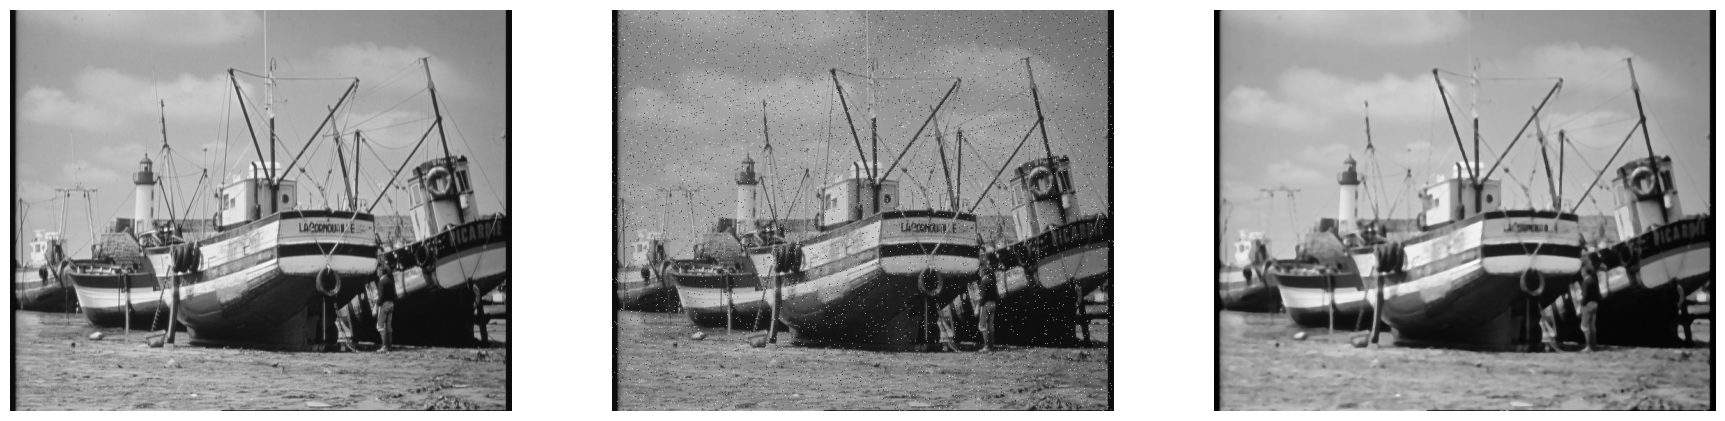

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import skimage.io as io
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.filters import median

# Read the image
img = io.imread( 'boats.bmp' )
len = np.size(img)

# Simulate salt and pepper noise
p = 0.01 # percentage of each
_idx = np.random.sample(img.shape) #uniform rand

img_noisy = img
# salt
img_noisy = np.where(_idx > 1.-p, 255, img)
# pepper pixels
img_noisy = np.where(_idx < p, 0, img_noisy)

# Apply median filtering
img_denoised = median(img_noisy, np.ones((5, 5)))

# Display
fig, axes = plt.subplots(ncols=3, figsize=(22,8))
axes[0].imshow(np.uint8(img), cmap=plt.get_cmap('gray'))
axes[1].imshow(np.uint8(img_noisy), cmap=plt.get_cmap('gray'))
axes[2].imshow(np.uint8(img_denoised), cmap=plt.get_cmap('gray'))

# Turn off axes for all subplots
p = [axi.set_axis_off() for axi in axes.ravel()]

# Get metrics
print('PSNR in: ' + str(psnr(img,img_noisy)) + '  SSIM in: ' +  str(ssim(img,img_noisy)))
print('PSNR out: ' + str(psnr(img,img_denoised)) + '  SSIM out: ' + str(ssim(img,img_denoised)))

<span style='color:red'><b>Exercise 1:</b></span> what is the optimal width of the filter, for a given value of p? Plot the PSNR and SSIM as a function of this width, conclude.

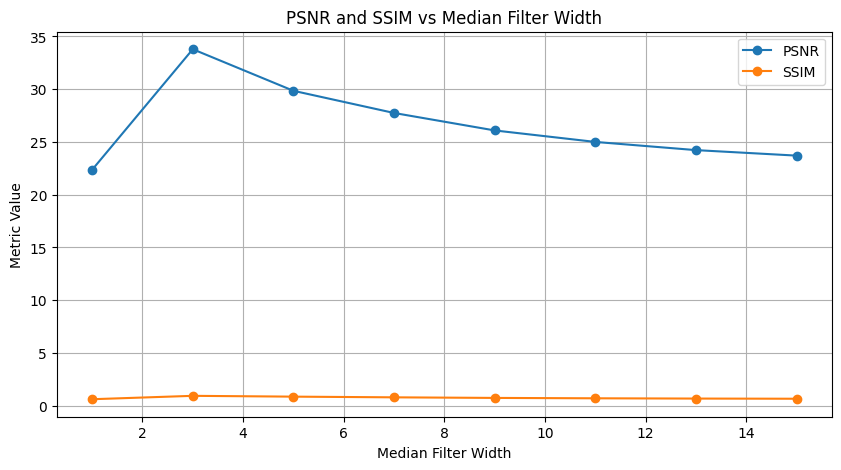

Best width (PSNR): 3
Best width (SSIM): 3


In [ ]:
# Read the image
img = io.imread('boats.bmp')

# Simulate salt and pepper noise
p = 0.01
_idx = np.random.sample(img.shape)

img_noisy = np.where(_idx > 1-p, 255, img)
img_noisy = np.where(_idx < p, 0, img_noisy)

# Test different filter widths
widths = np.arange(1, 16, 2)   # odd sizes: 1,3,5,...,15
psnr_vals = []
ssim_vals = []

for w in widths:
    kernel = np.ones((w, w))
    img_denoised = median(img_noisy, kernel)

    psnr_vals.append(psnr(img, img_denoised))
    ssim_vals.append(ssim(img, img_denoised))

# Plot results
plt.figure(figsize=(10,5))
plt.plot(widths, psnr_vals, '-o', label='PSNR')
plt.plot(widths, ssim_vals, '-o', label='SSIM')
plt.xlabel('Median Filter Width')
plt.ylabel('Metric Value')
plt.title('PSNR and SSIM vs Median Filter Width')
plt.legend()
plt.grid()
plt.show()

# Print best width
best_psnr_w = widths[np.argmax(psnr_vals)]
best_ssim_w = widths[np.argmax(ssim_vals)]

print("Best width (PSNR):", best_psnr_w)
print("Best width (SSIM):", best_ssim_w)

PSNR in: 22.31869288956809  SSIM in: 0.6035437121604765
PSNR out: 33.77222889735477  SSIM out: 0.9329755658105336


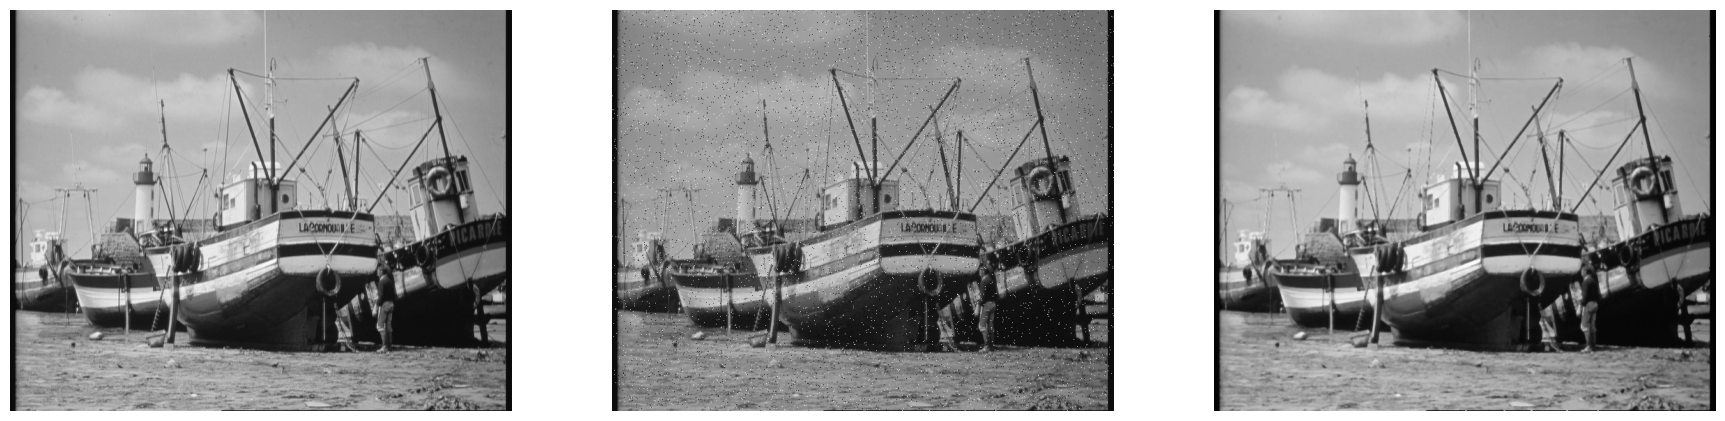

In [4]:
# Read the image
img = io.imread( 'boats.bmp' )
len = np.size(img)

# Simulate salt and pepper noise
p = 0.01 # percentage of each
_idx = np.random.sample(img.shape) #uniform rand

img_noisy = img
# salt
img_noisy = np.where(_idx > 1.-p, 255, img)
# pepper pixels
img_noisy = np.where(_idx < p, 0, img_noisy)

# Apply median filtering
img_denoised = median(img_noisy, np.ones((3, 3)))

# Display
fig, axes = plt.subplots(ncols=3, figsize=(22,8))
axes[0].imshow(np.uint8(img), cmap=plt.get_cmap('gray'))
axes[1].imshow(np.uint8(img_noisy), cmap=plt.get_cmap('gray'))
axes[2].imshow(np.uint8(img_denoised), cmap=plt.get_cmap('gray'))

# Turn off axes for all subplots
p = [axi.set_axis_off() for axi in axes.ravel()]

# Get metrics
print('PSNR in: ' + str(psnr(img,img_noisy)) + '  SSIM in: ' +  str(ssim(img,img_noisy)))
print('PSNR out: ' + str(psnr(img,img_denoised)) + '  SSIM out: ' + str(ssim(img,img_denoised)))

### Gaussian noise

We will now consider white Gaussian noise, a model commonly used in image processing. Be careful, we now need to work with floats !

The noisy image can be written $y=x+n$, with $n\sim\mathcal{N}(0,\sigma^2)$.

ValueError: Since image dtype is floating point, you must specify the data_range parameter. Please read the documentation carefully (including the note). It is recommended that you always specify the data_range anyway.

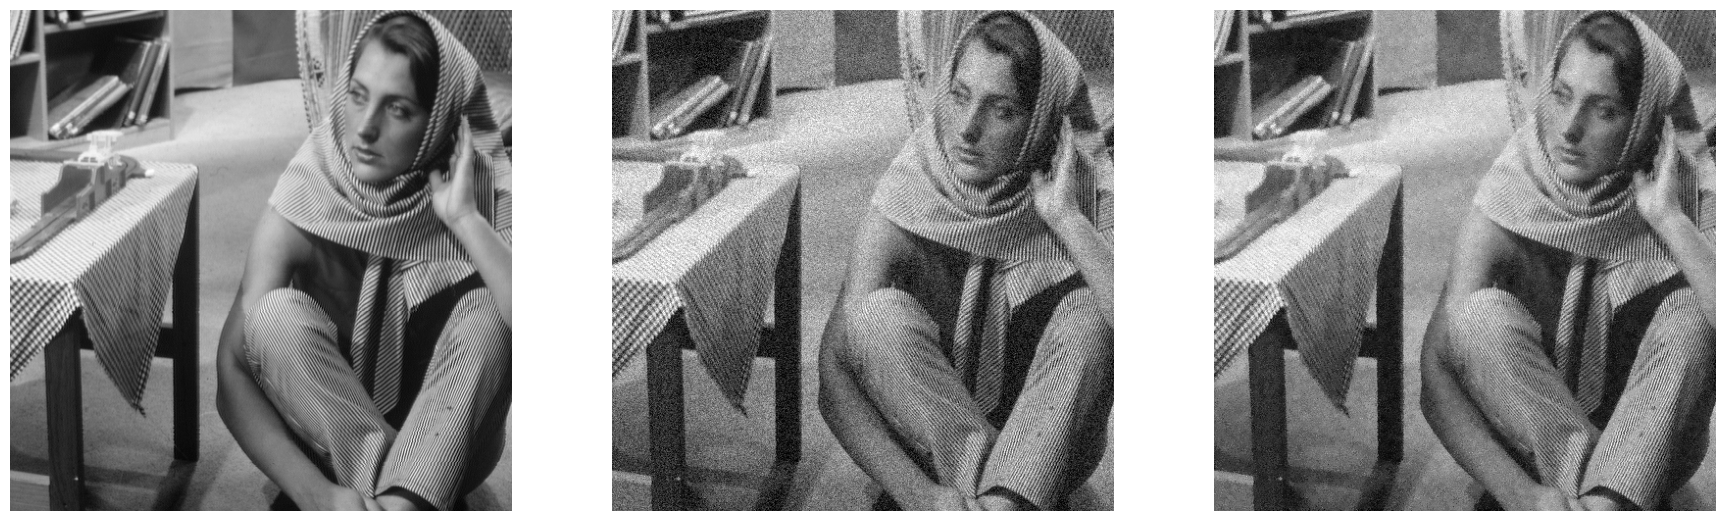

In [6]:
# Read the image
img = io.imread( 'barbara.pgm' )
img = img / 255.
sigma = 20. / 255
img_noisy = img + sigma * np.random.randn(*img.shape)
img_noisy = np.clip(img_noisy,0,1)

from skimage import restoration
img_denoised = restoration.denoise_bilateral(img_noisy, win_size=7, sigma_color=20./255, sigma_spatial=20) #, multichannel=True)
#img_denoised = restoration.denoise_nl_means(img_noisy, patch_size=5, patch_distance=21, h=15./255)

# Display
fig, axes = plt.subplots(ncols=3, figsize=(22,8))
axes[0].imshow(img, cmap=plt.get_cmap('gray'))
axes[1].imshow(img_noisy, cmap=plt.get_cmap('gray'))
axes[2].imshow(img_denoised, cmap=plt.get_cmap('gray'))

# Turn off axes for all subplots
p = [axi.set_axis_off() for axi in axes.ravel()]

print('PSNR in: ' + str(psnr(img,img_noisy)) + '  SSIM in: ' +  str(ssim(img,img_noisy,multichannel=False)))
print('PSNR out: ' + str(psnr(img,img_denoised)) + '  SSIM out: ' + str(ssim(img,img_denoised,multichannel=False)))

<span style='color:red'><b>Exercise 2:</b></span> 
- Try median filtering, then low-pass filtering. Are those techniques efficient?
- Try [bilateral filtering](https://scikit-image.org/docs/stable/api/skimage.restoration.html#skimage.restoration.denoise_bilateral), why does it work better?
- Try [non-local means](https://scikit-image.org/docs/stable/api/skimage.restoration.html#skimage.restoration.denoise_nl_means), why is the denoising still improved?

### Poisson-Gaussian noise (bonus)

A more realistic assumption accounts for Poisson noise, which is always present in images. The Poisson-Gaussian noise affecting a pixel $x$ can be written
$$ y \sim \gamma^{-1}\mathcal{P}(\gamma x) + \mathcal{N}(0,\sigma^2).$$

<span style='color:red'><b>Exercise 2 bis (bonus):</b></span> 
- Is this noise still additive?
- What is the variance of $y$?
- Explain why we can approximate this model by
$$y \sim x + \mathcal{N}(0,\sigma^2 + \gamma x).$$
- Simulate such a noise and apply NL-means. What can you observe on the estimated noise $\hat b$?

## 2. Image approximation and compression

We will now move to approximation and compression of images. We will apply some linear transforms such as DCT (discrete cosine transform) or DWT (discrete wavelet transform), and evaluate their performance in terms of image approximation.

Let us start by defining the DCT transform, its inverse and their block counterparts. We will then compute and display DCT and block-DCT on image *Barbara*. Since most of the energy is contained in the low frequencies, we will use a logarithmic display.

In [7]:
import scipy
import scipy.fftpack
from numpy import r_

# Define dct, idct, and block transforms
def dct2(a):
    return scipy.fftpack.dct( scipy.fftpack.dct( a, axis=0, norm='ortho' ), axis=1, norm='ortho' )

def idct2(a):
    return scipy.fftpack.idct( scipy.fftpack.idct( a, axis=0 , norm='ortho'), axis=1 , norm='ortho')

def block_dct2(im):
    imsize = im.shape
    dct = np.zeros(imsize)

    # Do 8x8 DCT on image (in-place)
    for i in r_[:imsize[0]:8]:
        for j in r_[:imsize[1]:8]:
            dct[i:(i+8),j:(j+8)] = dct2( im[i:(i+8),j:(j+8)] )
    return dct

def block_idct2(dct):
    imsize = dct.shape
    im = np.zeros(imsize)

    # Do 8x8 iDCT on image (in-place)
    for i in r_[:imsize[0]:8]:
        for j in r_[:imsize[1]:8]:
            im[i:(i+8),j:(j+8)] = idct2( dct[i:(i+8),j:(j+8)] )
    return im


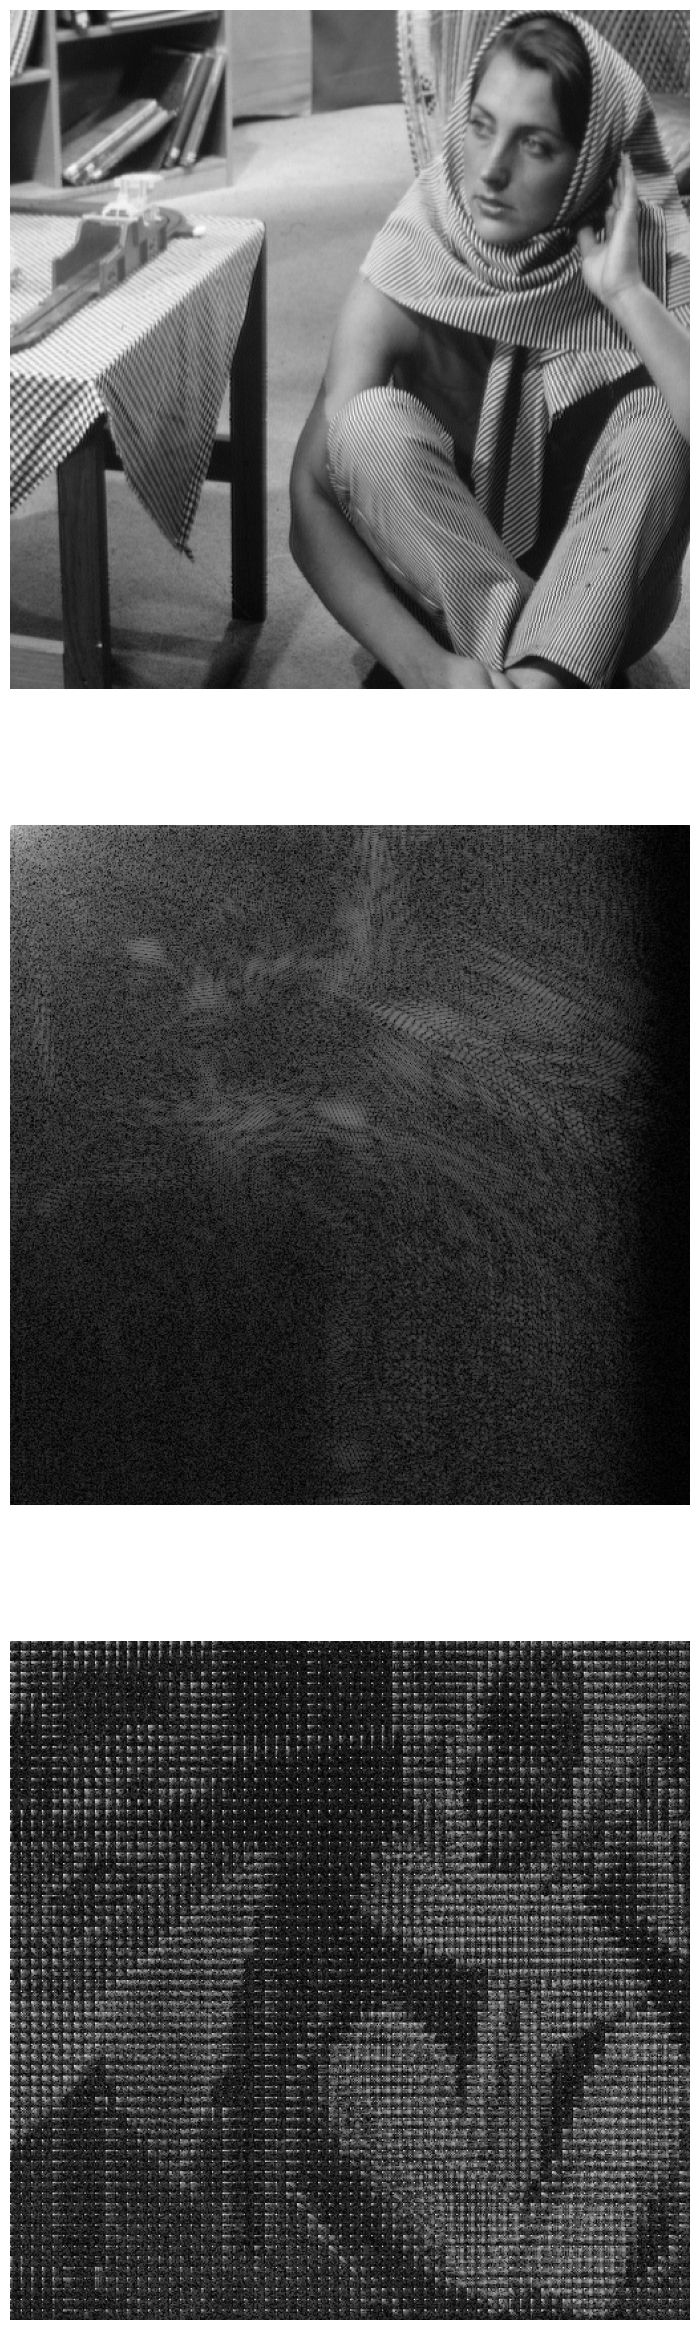

In [8]:
# Read the image
img = io.imread( 'barbara.pgm' )

# Compute DCT and block DCT
dct = dct2(img)
bdct = block_dct2(img)

# Display image and transforms
fig, axes = plt.subplots(nrows=3, figsize=(10,30))
axes[0].imshow(np.uint8(img), cmap=plt.get_cmap('gray'))
axes[1].imshow(np.log(1+np.abs(dct)), cmap=plt.get_cmap('gray'))
axes[2].imshow(np.log(1+np.abs(bdct)), cmap=plt.get_cmap('gray'))

# Turn off axes for all subplots
p = [axi.set_axis_off() for axi in axes.ravel()]

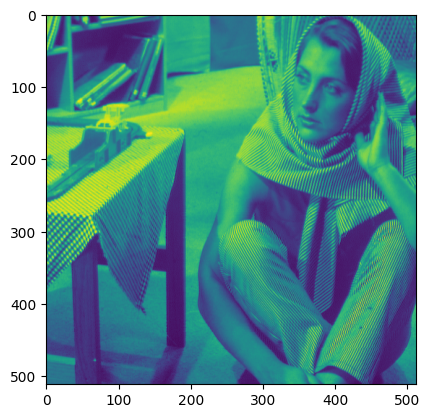

In [9]:
th = 40.
dct_thresh = np.where(np.abs(dct)<th, 0, dct)
img_rec = idct2(dct)
plt.imshow(img_rec)

The goal now is to approximate the image with few coefficients. To compare the different transformations, we will threshold the smallest coefficients, and see how this impacts the reconstruction of the image.

<span style='color:red'><b>Exercise 3:</b></span> 
- Set the the half smallest coefficients (in magnitude) to 0 for both transforms. Invert them, show the result and compute the PSNR and SSIM. You might use **np.median**.
- Do the same for other approximation rates (keep only 10% of the coefficients, then 20, 30, etc). You can use **np.quantile**. Show the usual metrics (PSNR and SSIM) as a function of the rate. Compare DCT and block DCT, and comment.
- (bonus) Do the same for a discrete wavelet transform.

The goal now is to understand the  link with image compression. Recall than in compression by transformation, a transform is first applied to the image, and the coefficients are then quantized and losslessly coded. The more "concentrate" the image coefficients, the better the result.

<span style='color:red'><b>Exercise 4:</b></span> 
- Display a small sample of a JPEG image, such as the provided *flower.jpg*
- Show some blocks that appear because of the JPEG compression
- Where is the quantization the most problematic?

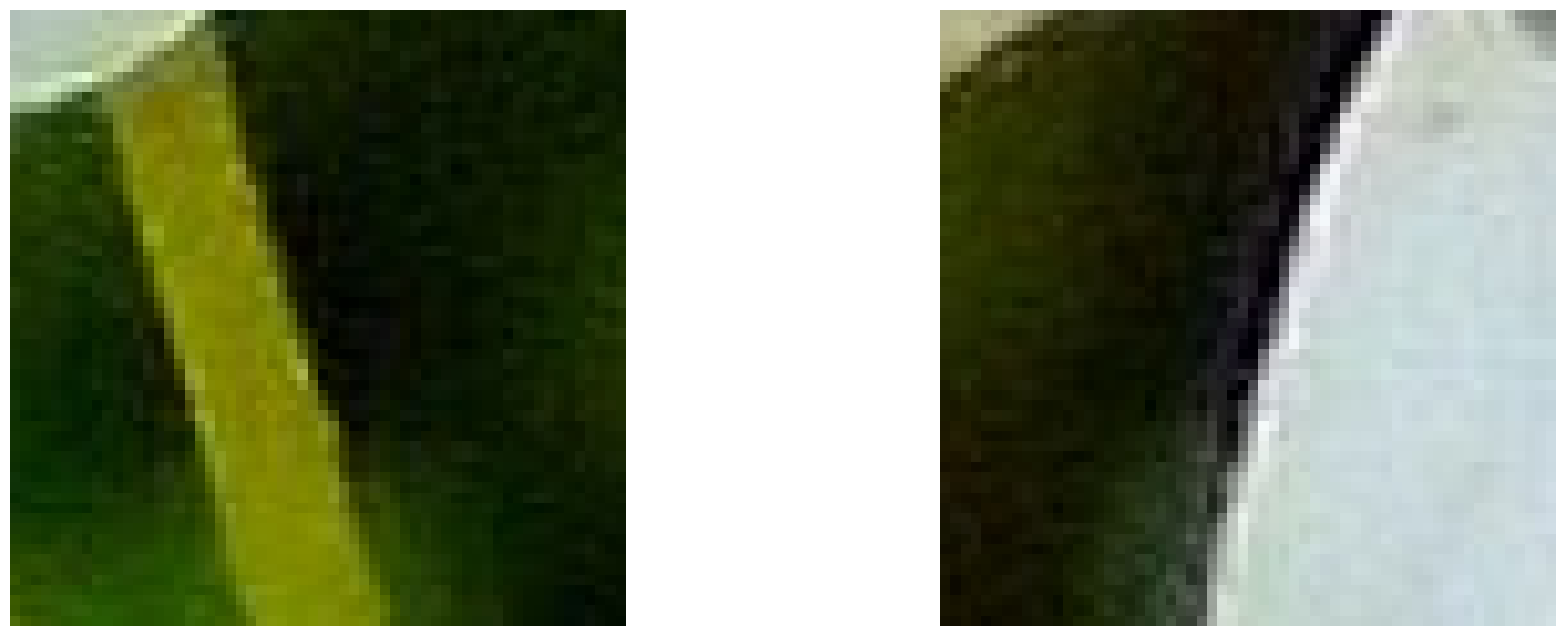

In [10]:
# Read the image
img = io.imread( 'flower.jpg' )
img = img / 255.

# Display
fig, axes = plt.subplots(ncols=2, figsize=(22,8))
axes[0].imshow(img[600:660,1000:1060,:])
axes[1].imshow(img[1100:1160,700:760,:])

# Turn off axes for all subplots
p = [axi.set_axis_off() for axi in axes.ravel()]